## BAT-II FINAL PROJECT

# Group Members
1. Lalain Khan
2. Samaa Shafqat
3. Sabeen Tahir
4. Kiran Sadaf
5. Humayun Sayed

In [1]:
#1 IMPORT LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    classification_report,
    accuracy_score,
    confusion_matrix,
    f1_score
)
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
#2 LOAD DATASET
df = pd.read_csv(r"C:\Users\sarbuland\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 7043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#3 DATA EXPLORATION

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


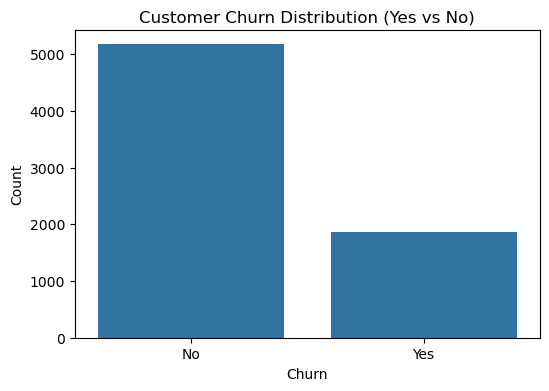

In [5]:
# Churn distribution
churn_counts = df['Churn'].value_counts()
print("Churn Distribution:")
print(churn_counts)

f, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution (Yes vs No)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [ ]:
#4 DATA PREPROCESSING & FEATURE ENGINEERING

In [6]:
print("TotalCharges dtype before fix:", df['TotalCharges'].dtype)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"NaN values introduced: {df['TotalCharges'].isna().sum()}")
print("Affected rows (tenure=0, not yet billed):")
print(df[df['TotalCharges'].isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("\nRemaining NaN in TotalCharges:", df['TotalCharges'].isna().sum())

TotalCharges dtype before fix: object
NaN values introduced: 11
Affected rows (tenure=0, not yet billed):
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN

Remaining NaN in TotalCharges: 0


In [7]:
# Final null check
print("Null values per column:")
print(df.isnull().sum())

Null values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
# Drop Irrelevant Columns
df = df.drop("customerID", axis=1)
print("customerID dropped. New shape:", df.shape)

customerID dropped. New shape: (7043, 20)


In [9]:
# Encode Target Variable
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

print("Churn encoded — Yes:1, No:0")
print(df["Churn"].value_counts())

Churn encoded — Yes:1, No:0
Churn
0    5174
1    1869
Name: count, dtype: int64


In [10]:
# Encode Binary Columns
df["gender"] = df["gender"].replace({"Female": 0, "Male": 1})

for col in ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]:
    df[col] = df[col].replace({"No": 0, "Yes": 1})

print("Binary columns encoded.")
df[['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']].head()

Binary columns encoded.


,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1


In [11]:
# One-Hot Encode Multi-Class Columns
multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]

print("Columns BEFORE encoding:", df.shape[1])
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
print("Columns AFTER encoding: ", df.shape[1])

Columns BEFORE encoding: 20
Columns AFTER encoding:  31


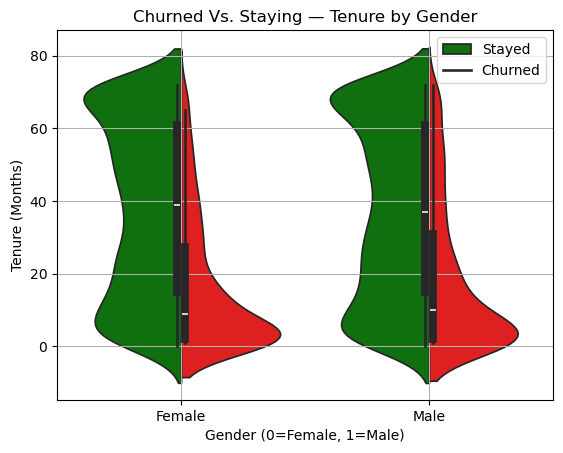

In [12]:
# Churn vs Gender vs Tenure
sns.violinplot(
    x='gender', y='tenure', hue='Churn',
    data=df,
    palette={0: 'green', 1: 'red'},
    split=True
)
plt.title("Churned Vs. Staying — Tenure by Gender")
plt.xlabel("Gender (0=Female, 1=Male)")
plt.ylabel("Tenure (Months)")
plt.xticks([0, 1], ['Female', 'Male'])
plt.legend(labels=['Stayed', 'Churned'])
plt.grid(True)
plt.show()

In [13]:
# Average monthly charge over contract life
df['AvgMonthlyCharge'] = df['TotalCharges'] / (df['tenure'] + 1)

# Number of active add-on services and charge per service
service_cols = [
    col for col in df.columns
    if any(svc in col for svc in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                                   'TechSupport', 'StreamingTV', 'StreamingMovies'])
    and '_Yes' in col
]
df['NumServices']      = df[service_cols].sum(axis=1)
df['ChargePerService'] = df['MonthlyCharges'] / (df['NumServices'] + 1)

# Tenure group — ordinal bin (0=New, 3=Champion)
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 36, 60, 72],
    labels=[0, 1, 2, 3]
).astype(int)

print("3 new features added: AvgMonthlyCharge, ChargePerService, TenureGroup")
print("Total features:", df.shape[1])

3 new features added: AvgMonthlyCharge, ChargePerService, TenureGroup
Total features: 35


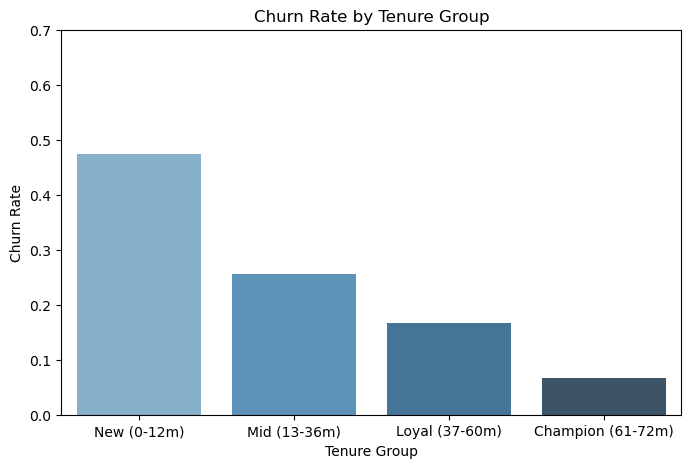

In [14]:
# Churn Rate by Tenure Group
churn_by_group = df.groupby('TenureGroup')['Churn'].mean().reset_index()
churn_by_group['TenureGroup'] = churn_by_group['TenureGroup'].replace(
    {0: 'New (0-12m)', 1: 'Mid (13-36m)', 2: 'Loyal (37-60m)', 3: 'Champion (61-72m)'}
)
plt.figure(figsize=(8, 5))
sns.barplot(x='TenureGroup', y='Churn', data=churn_by_group, palette='Blues_d')
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate")
plt.ylim(0, 0.7)
plt.show()

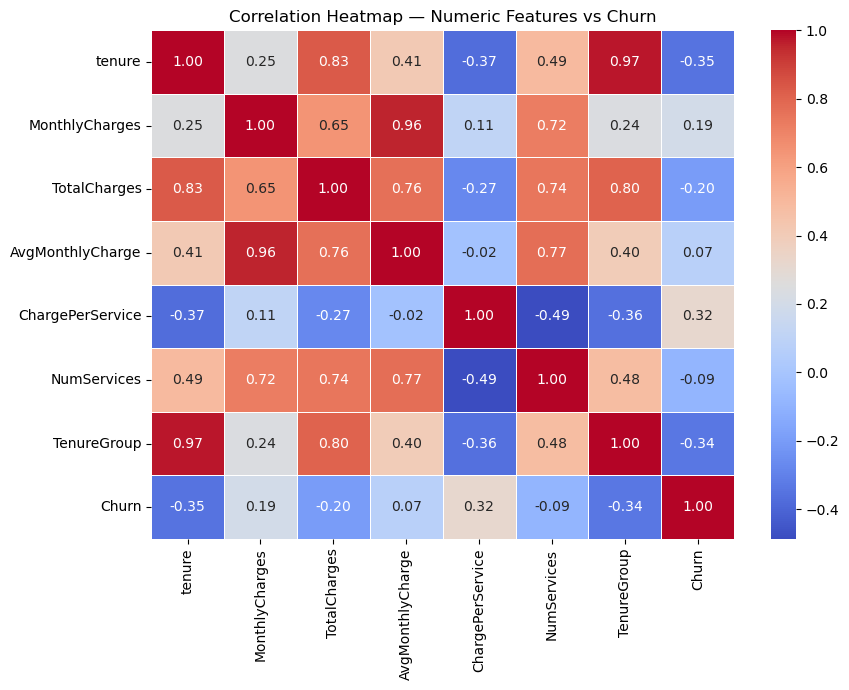

In [15]:
# Correlation heatmap
numeric_feature_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
                        'AvgMonthlyCharge', 'ChargePerService', 'NumServices',
                        'TenureGroup', 'Churn']
corr_matrix = df[numeric_feature_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap — Numeric Features vs Churn")
plt.tight_layout()
plt.show()

In [16]:
# Feature Scaling & Train-Test Split
X = df.drop("Churn", axis=1).values
y = df["Churn"].values

# Scale all features to [0, 1]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# 70% train / 30% test, stratified to preserve churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Churn ratio — train: {y_train.mean():.4f} | test: {y_test.mean():.4f}")

X_train: (4930, 34) | X_test: (2113, 34)
Churn ratio — train: 0.2653 | test: 0.2655


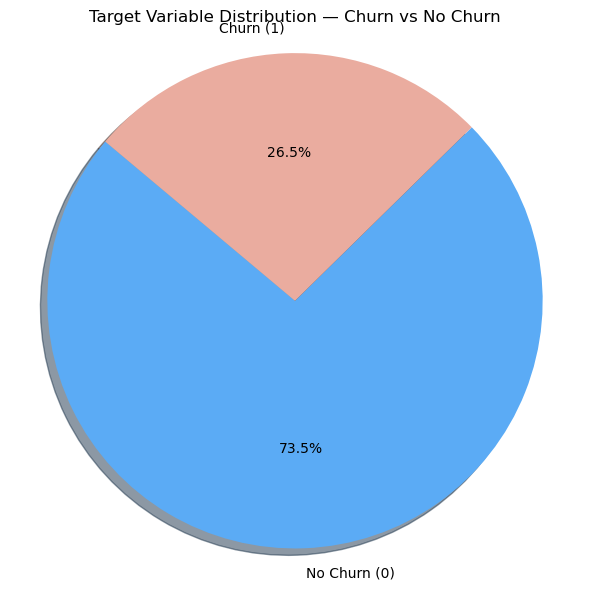

In [17]:
# Class imbalance pie chart
status_counts = pd.Series(y).value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    status_counts,
    labels=['No Churn (0)', 'Churn (1)'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#5BABF5', '#EAAC9F'],
    shadow=True
)
plt.title('Target Variable Distribution — Churn vs No Churn')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [18]:
# Helper Functions, Reused After Every Model
def plot_confusion_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(pd.DataFrame(cm), annot=True, fmt='g', cmap='Blues')
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks([0.5, 1.5], ['Stayed (0)', 'Churned (1)'])
    plt.yticks([0.5, 1.5], ['Stayed (0)', 'Churned (1)'])
    plt.show()

def plot_roc_curve(y_test, y_prob, title):
    fRate, tRate, thresh = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob) * 100
    plt.figure(figsize=(8, 6))
    plt.plot(fRate, tRate, label=f"ROC Curve (AUC = {auc:.2f}%)")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Baseline")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title(f"ROC Curve — {title}")
    plt.legend()
    plt.grid(True)
    plt.show()
    return auc

In [ ]:
#5 Model 1 — Gaussian Naive Bayes

In [19]:
params = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

nb = GaussianNB()

clf = GridSearchCV(nb, param_grid=params, cv=5, verbose=True, n_jobs=-1)
OptimalModel_NB = clf.fit(X_train, y_train)

print("\nBest params:", clf.best_params_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best params: {'var_smoothing': np.float64(0.0006579332246575676)}


In [20]:
nb_prob = OptimalModel_NB.predict_proba(X_test)[:, 1]
nb_pred = OptimalModel_NB.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred) * 100
nb_f1  = f1_score(y_test, nb_pred) * 100

print(f"Accuracy : {nb_acc:.2f}%")
print(f"F1 Score : {nb_f1:.2f}%")
print()
print(classification_report(y_test, nb_pred, target_names=['Stayed', 'Churned']))

Accuracy : 67.01%
F1 Score : 58.04%

              precision    recall  f1-score   support

      Stayed       0.92      0.60      0.73      1552
     Churned       0.44      0.86      0.58       561

    accuracy                           0.67      2113
   macro avg       0.68      0.73      0.65      2113
weighted avg       0.79      0.67      0.69      2113



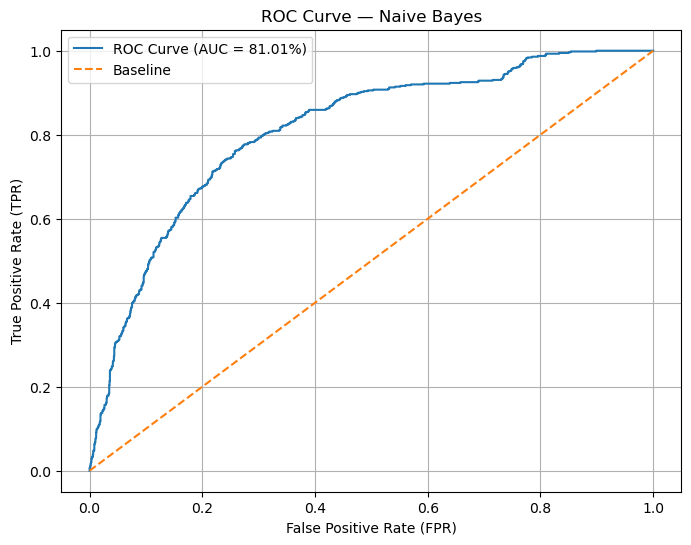

Optimal AUC: 81.0109%


In [21]:
nb_auc = plot_roc_curve(y_test, nb_prob, "Naive Bayes")
print(f"Optimal AUC: {nb_auc:.4f}%")

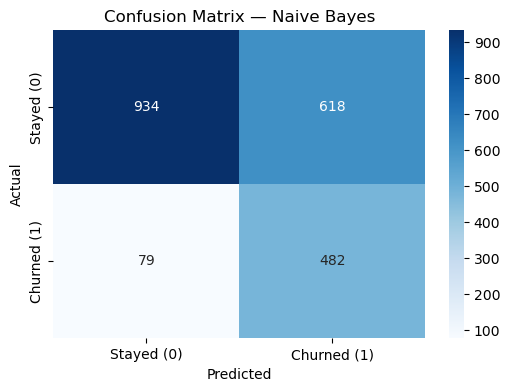

In [22]:
plot_confusion_matrix(y_test, nb_pred, "Naive Bayes")

In [ ]:
#6 Model 2 — K-Nearest Neighbours (KNN)

In [23]:
knn = KNeighborsClassifier()

parameters = {
    'n_neighbors': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21]
}

gridcv = GridSearchCV(
    knn,
    param_grid=parameters,
    cv=10,
    scoring='accuracy'
)

OptimalModel_KNN = gridcv.fit(X_train, y_train)

print("Optimal Model - K Value:", gridcv.best_params_)
print("Optimal Model - Accuracy:", gridcv.best_score_ * 100, "%")

Optimal Model - K Value: {'n_neighbors': 20}
Optimal Model - Accuracy: 78.66125760649088 %


In [24]:
knn_prob = OptimalModel_KNN.predict_proba(X_test)[:, 1]
knn_pred = OptimalModel_KNN.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred) * 100
knn_f1  = f1_score(y_test, knn_pred) * 100

print(f"Accuracy : {knn_acc:.2f}%")
print(f"F1 Score : {knn_f1:.2f}%")
print()
print(classification_report(y_test, knn_pred, target_names=['Stayed', 'Churned']))

Accuracy : 78.51%
F1 Score : 55.84%

              precision    recall  f1-score   support

      Stayed       0.83      0.88      0.86      1552
     Churned       0.61      0.51      0.56       561

    accuracy                           0.79      2113
   macro avg       0.72      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



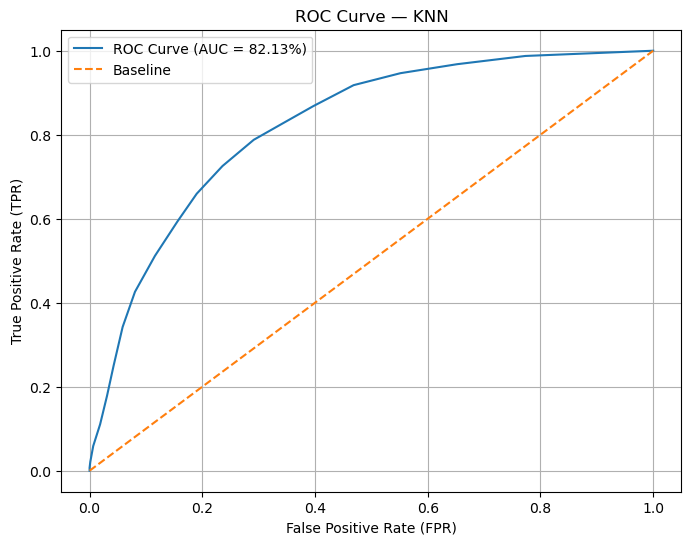

Optimal AUC: 82.1285%


In [25]:
knn_auc = plot_roc_curve(y_test, knn_prob, "KNN")
print(f"Optimal AUC: {knn_auc:.4f}%")

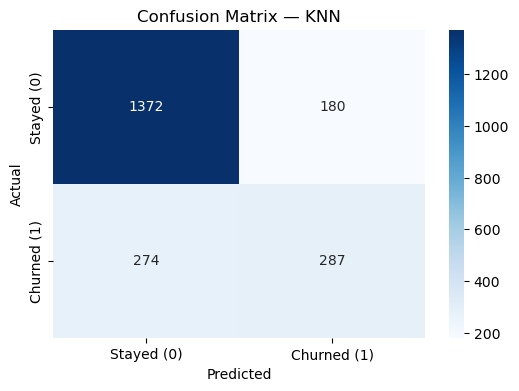

In [26]:
plot_confusion_matrix(y_test, knn_pred, "KNN")

In [27]:
#7 Model 3 — XGBoost
# scale_pos_weight handles class imbalance (73% stayed / 27% churned)
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale:.2f}")

xgb = XGBClassifier(
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)

params_xgb = {
    'n_estimators': [100, 200],
    'max_depth':    [3, 5],
    'learning_rate':[0.05, 0.1]
}

gridcv_xgb = GridSearchCV(xgb, param_grid=params_xgb, cv=5, scoring='accuracy', n_jobs=-1)
OptimalModel_XGB = gridcv_xgb.fit(X_train, y_train)

print("Best params:", gridcv_xgb.best_params_)
print("Best CV Accuracy:", round(gridcv_xgb.best_score_ * 100, 2), "%")

scale_pos_weight = 2.77
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV Accuracy: 75.92 %


In [28]:
xgb_prob = OptimalModel_XGB.predict_proba(X_test)[:, 1]
xgb_pred = OptimalModel_XGB.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred) * 100
xgb_f1  = f1_score(y_test, xgb_pred) * 100

print(f"Accuracy : {xgb_acc:.2f}%")
print(f"F1 Score : {xgb_f1:.2f}%")
print()
print(classification_report(y_test, xgb_pred, target_names=['Stayed', 'Churned']))

Accuracy : 75.06%
F1 Score : 60.88%

              precision    recall  f1-score   support

      Stayed       0.89      0.76      0.82      1552
     Churned       0.52      0.73      0.61       561

    accuracy                           0.75      2113
   macro avg       0.70      0.74      0.71      2113
weighted avg       0.79      0.75      0.76      2113



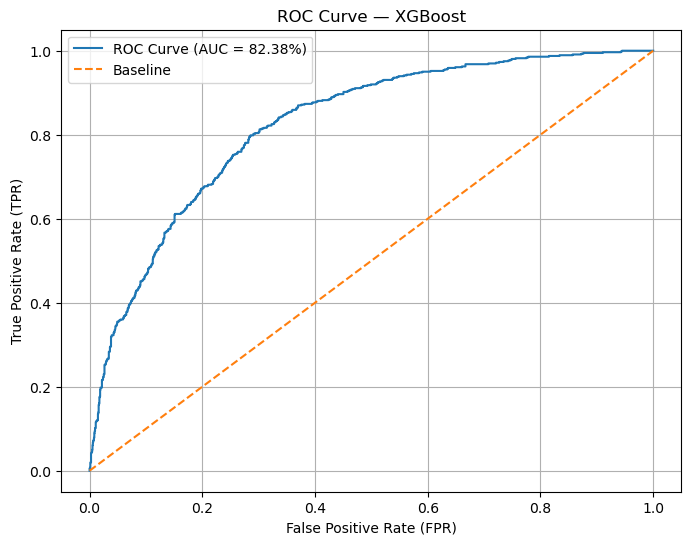

Optimal AUC: 82.3831%


In [29]:
xgb_auc = plot_roc_curve(y_test, xgb_prob, "XGBoost")
print(f"Optimal AUC: {xgb_auc:.4f}%")

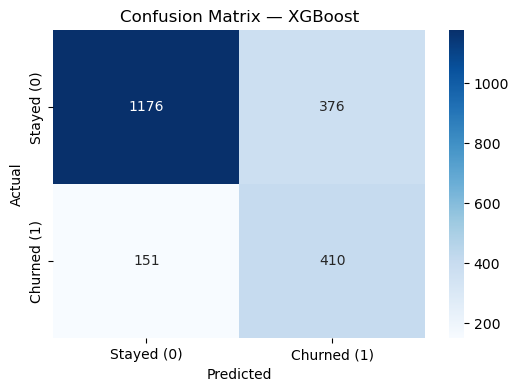

In [30]:
plot_confusion_matrix(y_test, xgb_pred, "XGBoost")

In [ ]:
#8 Model Comparison

In [31]:
results = pd.DataFrame({
    'Model':    ['Naive Bayes', 'KNN', 'XGBoost'],
    'Accuracy': [round(nb_acc, 2), round(knn_acc, 2), round(xgb_acc, 2)],
    'F1 Score': [round(nb_f1, 2),  round(knn_f1, 2),  round(xgb_f1, 2)],
    'AUC-ROC':  [round(nb_auc, 2), round(knn_auc, 2), round(xgb_auc, 2)]
})

print(results.to_string(index=False))

      Model  Accuracy  F1 Score  AUC-ROC
Naive Bayes     67.01     58.04    81.01
        KNN     78.51     55.84    82.13
    XGBoost     75.06     60.88    82.38


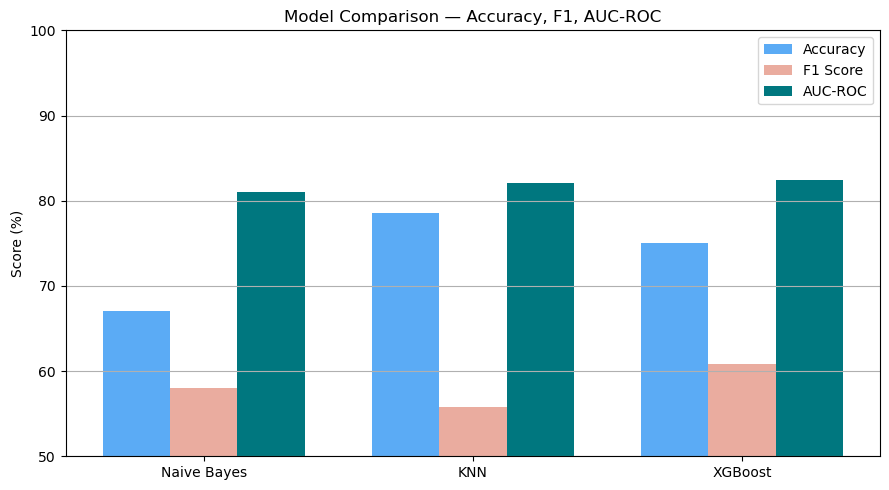

In [32]:
x = np.arange(len(results['Model']))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, results['Accuracy'], width, label='Accuracy',  color='#5BABF5')
plt.bar(x,         results['F1 Score'], width, label='F1 Score',  color='#EAAC9F')
plt.bar(x + width, results['AUC-ROC'],  width, label='AUC-ROC',   color='#00777F')

plt.xticks(x, results['Model'])
plt.ylabel('Score (%)')
plt.title('Model Comparison — Accuracy, F1, AUC-ROC')
plt.legend()
plt.ylim(50, 100)
plt.grid(axis='y')
plt.tight_layout()
plt.show()